# Basic Python
## Part 1: Logic and String Manipulation

**1.a The DNA Helix Printer**
Write a function `print_helix(n, turns)` where `n` is the width of the helix and `turns` is the number of full cycles. The helix is formed by two strands.
* The strands oscillate using a sine-wave-like pattern.
* The characters for the strands should cycle through `A, C, G, T`.
* **Constraint:** You must handle the spacing dynamically.

**Example Output (`n=4, turns=1`):**
```text
A      A
 C    C
  G  G
   TT
  A  A
 C    C
G      G

In [13]:
def print_helix(n, turns):
    # TODO: Implement the pattern logic here
    #base pattern generation
    bases={1:'A',2:'C',3:'G',4:'T'}

    pattern=""
    for j in range(1,n+1):
        base=bases[((j-1)%4)+1]
        spaces1=" "*(n-j)*2
        spaces2=" "*(j-1)
        pattern+=spaces2+base+spaces1+base+"\n"
    for j in range(1,n):
        base=bases[((j-1)%4)+1]
        spaces1=" "*(n-j-1)
        spaces2=" "*(j)*2
        pattern+=spaces1+base+spaces2+base+"\n"
    
    for _ in range(turns):
        print(pattern, end='')

# Test
print_helix(4, 3)

A      A
 C    C
  G  G
   TT
  A  A
 C    C
G      G
A      A
 C    C
  G  G
   TT
  A  A
 C    C
G      G
A      A
 C    C
  G  G
   TT
  A  A
 C    C
G      G


**1.b The Custom Sorter**
Write a function `sort_strings(s_list)` that takes a list of strings and sorts them based on the following priority rules:
1.  **Primary:** Length of the string (Ascending).
2.  **Secondary:** Number of distinct vowels (a, e, i, o, u) present in the string (Descending).
3.  **Tertiary:** Alphabetical order (Ascending).

**Example:**
Input: `["apple", "banana", "kiwi", "sky", "aieou", "z"]`
Output: `['z', 'sky', 'kiwi', 'aieou', 'apple', 'banana']`

In [15]:
def sort_strings(s_list):
    def get_vowel_count(s):
        vowels = "aeiou"
        # Convert to lowercase to count 'A' and 'a' together, etc.
        # Use a set comprehension to find the distinct vowels in the string
        return len({char for char in s.lower() if char in vowels})

# The dictionary comprehension
    dict = {
        s: (
            len(s),  # 1) Length of the string
            get_vowel_count(s)*-1,  # 2) Number of distinct vowels
            ord(s[0].lower())  # 3) ASCII code of first letter (lowercase)
        )
        for s in s_list
    }
    # Sort the strings based on the tuple values in the dictionary
    sorted_strings = sorted(dict.keys(), key=lambda s: dict[s])
    return sorted_strings

# Test
data = ["apple", "banana", "kiwi", "sky", "aieou", "z"]
print(sort_strings(data))

['z', 'sky', 'kiwi', 'aieou', 'apple', 'banana']


## Part 2: Working with Data

Consider that you are processing raw data from a sensor in a physics lab. The sensor is noisy and occasionally malfunctions.

**Task:**
1.  Read the file ```sensor_logs.csv``` **without using Pandas**.
2.  **Filter:** Ignore rows where `status` is "ERR" OR `voltage` > 10.0.
3.  **Analysis:** Calculate the **Mean** and **Standard Deviation** for each sensor.

In [17]:
import math
import pandas as pd

def analyze_sensors(filename, data_column="voltage"):

    df = pd.read_csv(filename)


    condition_A = (df[data_column] <= 100)


    condition_B = (df['status'] != 'ERR')


    filtered_df = df[condition_A & condition_B]

    mean_value = filtered_df[data_column].mean()
    std_dev = filtered_df[data_column].std()
    print(f"Mean: {mean_value}, Standard Deviation: {std_dev}")
    return mean_value, std_dev



analyze_sensors("sensor_log.csv")

Mean: 3.9916344086021507, Standard Deviation: 0.5747997362077778


(np.float64(3.9916344086021507), np.float64(0.5747997362077778))

## SciPy

### Task 1

Find the positive root of the transcendental equation: $x^2 - 5\sin(x) - 2 = 0$

In [19]:
# TODO 1
import numpy as np
from scipy.optimize import newton


def f(x):
    return x**2 - 5 * np.sin(x) - 2

def df(x):
    return 2 * x - 5 * np.cos(x)

# We provide an initial guess and the derivative function (fprime)
initial_guess = 2.0
root_newton = newton(f, initial_guess, fprime=df)

print(f"Root found by newton: {root_newton:.12f}")

Root found by newton: 2.354238948337


### Task 2
Simulate a radioactive decay chain: $A \to B \to C$ (Stable).

* $\frac{dA}{dt} = -k_1 A$
* $\frac{dB}{dt} = k_1 A - k_2 B$
* $\frac{dC}{dt} = k_2 B$

Given $k_1 = 0.5$, $k_2 = 0.1$. Initial conditions: $A_0 = 100$, $B_0 = 0$, $C_0 = 0$.

You have to find the concentration of **B at t = 5.0**.

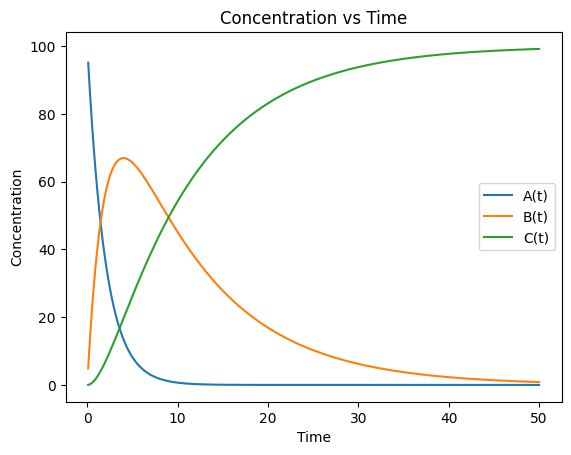

65.5760704729057


In [29]:
# TODO 2
import numpy as np
import matplotlib.pyplot as plt
# You can define any helper function if needed
dt=0.01
k1=0.5
k2=0.1
A=100
B=0
C=0
timepoints,Apoints,Bpoints,Cpoints=[],[],[],[]
t=0.0
while t<50.00:
    dA_dt = -k1 * A
    dB_dt = k1 * A - k2 * B
    dC_dt = k2 * B

    A += dA_dt * dt
    B += dB_dt * dt
    C += dC_dt * dt

    t += dt
    if int(t*100)%10==0:
        timepoints.append(t)
        Apoints.append(A)
        Bpoints.append(B)
        Cpoints.append(C)
plt.plot(timepoints, Apoints, label='A(t)')
plt.plot(timepoints, Bpoints, label='B(t)')
plt.plot(timepoints, Cpoints, label='C(t)')
plt.xlabel('Time')
plt.ylabel('Concentration')
plt.title('Concentration vs Time')
plt.legend()
plt.show()
print(Bpoints[int(0.50/dt)])




# The N-Body Problem
In classical mechanics, the Two-Body problem (e.g., Earth-Moon) has an analytical solution. However, adding a third body makes the system unsolvable by pen and paper. To predict the motion of star clusters or galaxies, we solve the **N-Body problem** numerically.

**Objective:** Your task is to implement a vectorized N-Body simulation using Python and NumPy.

**Important: You are not allowed to use any loops for physics calculations.**

### The Physics & The Numerical Problem

The acceleration $\vec{a}_i$ acting on particle $i$ is the sum of gravitational forces from all other particles $j$.
$$\vec{a}_i = \sum_{j \neq i} G \cdot m_j \cdot \frac{\vec{r}_j - \vec{r}_i}{|\vec{r}_j - \vec{r}_i|^3}$$

**The Numerical Issue:**
As particles get close, $|\vec{r}_j - \vec{r}_i| \to 0$, causing the force to shoot to infinity (Singularity). In a discrete time-step simulation, this flings particles out of the galaxy at unphysical speeds.

**Q. Explain, how would you overcome this issue (you may introduce additional parameters if needed)?**

**Q. Does the value of your param ```affect``` your results? If they do then explain how.**

### Setup and Initialization

Run this cell to import libraries and set up the simulation environment. **Do not modify this cell.**

In [33]:
import numpy as np
import matplotlib.pyplot as plt
import time

# Simulation Parameters

G = 1.0           # Gravitational Constant
PARAM = 0.1       # Your parameter (if needed)
DT = 0.01         # Time step
STEPS = 200       # Number of steps
N_PARTICLES = 100 # Number of particles

def generate_initial_state(N, seed=42):
    """
    Generates N random particles.
    Returns:
        positions: (N, 2) array
        velocities: (N, 2) array
        masses: (N,) array
    """
    np.random.seed(seed)
    positions = np.random.randn(N, 2)
    velocities = np.random.randn(N, 2) * 0.5
    masses = np.random.rand(N) + 0.5 # Masses between 0.5 and 1.5
    return positions, velocities, masses


In [ ]:
# TODO 1 : Calculates the net acceleration on every particle due to every other particle.
# You should return accelerations as a (N, 2) numpy array representing a_x, a_y

def calculate_accelerations(positions, masses, G=1.0, param=0.1):

    # TODO 1.1: Calculate the displacement vector matrix (N, N, 2)
    # Use broadcasting preferably it would be awarded accordidngly
    disp_matrix = positions[np.newaxis, :, :] - positions[:, np.newaxis, :]
    
    # TODO 1.2: Calculate the distance squared matrix (N, N)
    dist_sq_matrix = np.sum(disp_matrix**2, axis=2)+param**2 ## Adding softening factor to avoid division by zero
    # TODO 1.3: Find the acceleration (N, 2)
    distance_term = dist_sq_matrix**(-1.5)
    mass_factor = masses[np.newaxis, :]
    magnitude_factor = G * mass_factor * distance_term
    np.fill_diagonal(magnitude_factor, 0)
    #accelerations = np.einsum('ijk,ij->ik', disp_matrix, magnitude_factor)
    acceleration_matrix = magnitude_factor[:, :, np.newaxis] * disp_matrix
    net_acceleration = np.sum(acceleration_matrix, axis=1)

    return net_acceleration 


In [35]:
# TODO 2: Updates the simulation by one timestep.

def symplectic_euler_step(positions, velocities, accelerations, dt):
    # TODO 2.1: Update velocities and then positions using the formulas above.
    velocities += accelerations * dt
    positions += velocities * dt
    
    return positions, velocities

## Visualization

If your code is correct, this block will run the simulation and produce a plot.

**Note:** This block checks if your functions are implemented. If they return `None` or zeros, the plot will look static or empty.

Simulation of 100 particles for 200 steps took: 0.0995s


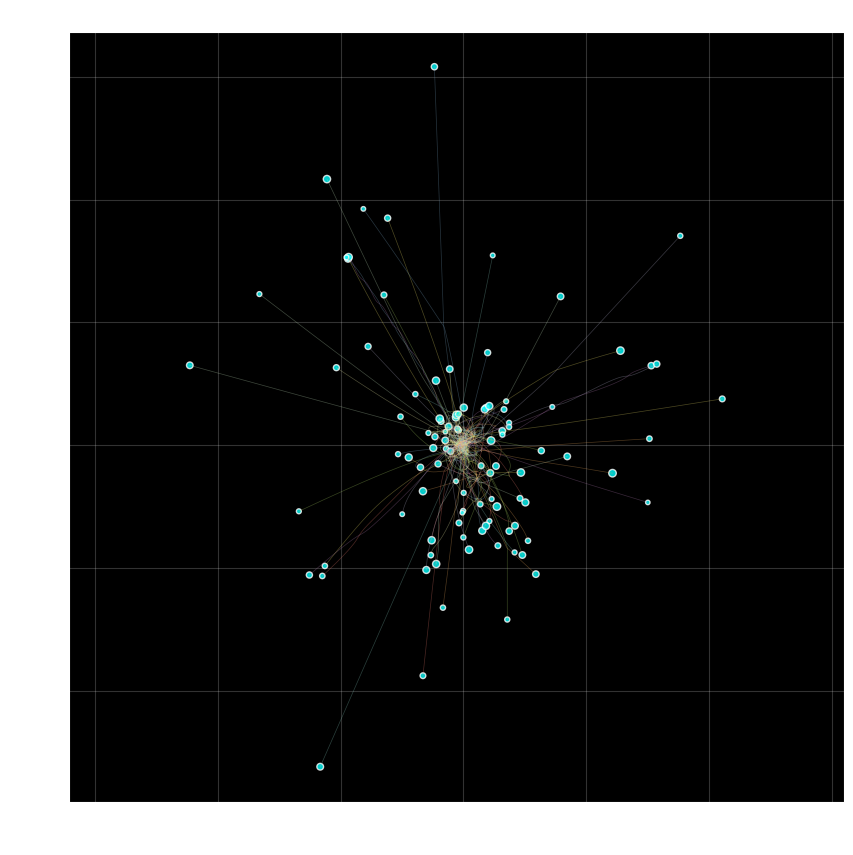

In [36]:
def run_simulation(N=100, steps=200, dt=0.01):
    positions, velocities, masses = generate_initial_state(N)
    
    trajectory_history = []
    trajectory_history.append(positions.copy())
    
    start_time = time.time()
    
    for _ in range(steps):
        # Calculate forces
        acc = calculate_accelerations(positions, masses, G, PARAM)
        
        # Integrate
        positions, velocities = symplectic_euler_step(positions, velocities, acc, dt)
        
        # Store history
        trajectory_history.append(positions.copy())
        
    end_time = time.time()
    print(f"Simulation of {N} particles for {steps} steps took: {end_time - start_time:.4f}s")
    
    return np.array(trajectory_history), masses

# Main Simualtion
history, masses = run_simulation(N=N_PARTICLES, steps=STEPS, dt=DT)

plt.figure(figsize=(10, 10))
plt.style.use('dark_background')

for i in range(N_PARTICLES):
    plt.plot(history[:, i, 0], history[:, i, 1], alpha=0.3, lw=0.5)

# Plot final positions
plt.scatter(history[-1, :, 0], history[-1, :, 1], s=masses*20, c='cyan', alpha=0.8, edgecolors='white')

plt.title(f"N-Body Simulation (N={N_PARTICLES})")
plt.xlabel("x")
plt.ylabel("y")
plt.grid(True, alpha=0.2)
plt.axis('equal')
plt.show()

## Conservation of Energy

A good physics simulation must conserve energy. 
* **Kinetic Energy (T):** $T = \frac{1}{2} \sum m_i v_i^2$
* **Potential Energy (U):** $U = -\frac{1}{2} \sum_i \sum_{j \neq i} \frac{G m_i m_j}{r_{ij}}$

**Note that the energy functions can also change depending on how you chose the parameter, so if you make any such modification, explain that clearly.**

**Task:** Implement the energy calculation.

In [39]:
# TODO 3: Calculate the Total Energy (Kinetic + Potential).

def calculate_total_energy(positions, velocities, masses, G=1.0, param=0.1):
    # TODO 3.1: Calculate Kinetic Energy
    T = 0.0
    kinetic_energies = 0.5 * masses * np.sum(velocities**2, axis=1)
    T = np.sum(kinetic_energies)
    
    # TODO 3.2: Calculate Potential Energy
    # Hint: You can reuse the distance matrix logic from Task 1
    U = 0.0
    disp_matrix = positions[np.newaxis, :, :] - positions[:, np.newaxis, :]
    dist_sq_matrix = np.sum(disp_matrix**2, axis=2)
    dist_matrix = np.sqrt(dist_sq_matrix)+param
    inv_dist_matrix = dist_matrix**-1
    U_matrix = -0.5 * G * (masses[:, np.newaxis] * masses[np.newaxis, :]) * inv_dist_matrix
    U_matrix[np.diag_indices_from(U_matrix)] = 0
    U = np.sum(U_matrix)
    return T + U

# Test for a simple 2-body static case
pos_test = np.array([[1.0, 0.0], [-1.0, 0.0]])
vel_test = np.array([[0.0, 0.0], [0.0, 0.0]])
mass_test = np.array([1.0, 1.0])

E_check = calculate_total_energy(pos_test, vel_test, mass_test, G=1.0, param=0.01)
print(f"Test Case Energy: {E_check:.4f} (Expected: -0.500)")

Test Case Energy: -0.4975 (Expected: -0.500)


# Cause of mismatch

As described above , the softening term introduces an error in order to account for zero divison. It effect can be minimized by adding the softening term only to zero values instead of all values

## Detailed effect of the softening term
Since the effective distance used for computation is more than the actual distance, we exxpect a higher total energy than the actual energy.

## Advanced Integration with SciPy

In computational physics, we often use established libraries to verify our manual implementations. SciPy's `solve_ivp` is a powerful integrator with adaptive time-stepping.

**The Challenge:** `solve_ivp` requires the system state to be a **1D array**. You currently have 2D arrays for positions and velocities.

**TODO:**
1.  Flatten your initial `positions` and `velocities` into a single 1D array `y0`.
2.  Implement the derivative function `nbody_ode(t, y, masses, ...)` which:
    * Unpacks the 1D `y` back into `positions` and `velocities`.
    * Calculates `accelerations` using your function from Task 1.
    * Returns the derivatives (velocities and accelerations) as a flattened 1D array.
3.  Run the solver.

## 8. Task 4: Advanced Integration with SciPy
Run the simulation using `solve_ivp`.

In [41]:
from scipy.integrate import solve_ivp

# TODO 4: Implement a function nbody_ode that bridges the gap between scipy 1D requirement and your 2D logic.

def nbody_ode(t, y, masses, G):
    """
    This function takes in
        t: float, current time
        y: 1D numpy array, current state vector
        masses: (N,) array
        G: float

    This should return an array (dydt) i.e.
        1D numpy array, which time derivative of the state vector
    """
    
    # TODO 4.1: Unpack the 1D state vector 'y' into positions (N, 2) and velocities (N, 2)
    positions = y[:len(y)//2].reshape(-1, 2)
    velocities = y[len(y)//2:].reshape(-1, 2)
    # TODO 4.2: Calculate accelerations
    accelerations = calculate_accelerations(positions, masses, G)
    # Hint: you can reuse your previous functio)
    
    # TODO 4.3: Pack the derivatives (velocities and accelerations) back into a 1D array
    y1= np.concatenate([velocities.flatten(), accelerations.flatten()])

    
    return y1 # Placeholder

In [42]:
# TODO 5: Run the simulation using solve_ivp.

N_SCIPY = 10
pos_s, vel_s, mass_s = generate_initial_state(N_SCIPY)
t_span = (0, 2.0)
print(f"Running SciPy Integrator for N={N_SCIPY}...")

# TODO 5.1: Prepare the initial 1D state vector 'y0' from pos_s and vel_s
y0 = np.concatenate([pos_s.flatten(), vel_s.flatten()])
# TODO 5.2: Call solve_ivp

sol = solve_ivp(nbody_ode, t_span, y0, args=(mass_s, G), method='RK45', t_eval=np.linspace(t_span[0], t_span[1], 200))
#sol = None

if sol:
    print(f"SciPy solved in {len(sol.t)} steps.")
    print(f"Final shape of solution: {sol.y.shape}")

Running SciPy Integrator for N=10...
SciPy solved in 200 steps.
Final shape of solution: (40, 200)


# Damped coupled oscillators

The bobs of two pendulums are connected by a spring, forming a coupled oscillator system. Real systems always have some damping, in which mechanical energy is slowly converted to heat. For this problem we model the damping as a force proportional to velocity. Assume that the spring is ideal and that the system is placed on the surface of an unknown extremely large planet. Let $\theta_1$ and $\theta_2$ denote the angles that pendulum strings make with the vertical and $t$ denote time. The equations governing the motion of the system can be written as

$$ \frac{d^2 \theta_1}{d t^2} = -c_1 \frac{d \theta_1}{d t} - k_1 \theta_1 -k_c (\theta_1 - \theta_2)$$
$$ \frac{d^2 \theta_2}{d t^2} = -c_2 \frac{d \theta_2}{d t} - k_2 \theta_2 -k_c (\theta_2 - \theta_1)$$

The file `data.csv` provides you measurements for $\theta_1$ and $\theta_2$ with time. Your task is to find $c_1, c_2, k_1, k_2, k_c$ using python (numpy and/or pandas). Note that the data might have noise and also be partially corruped due to limitations of measuring instruments.  Plot the values of $\theta_1$ and $\theta_2$ predicted using the constants calculated above against the measured values. Assume arbitrary (but consistent) unit system.

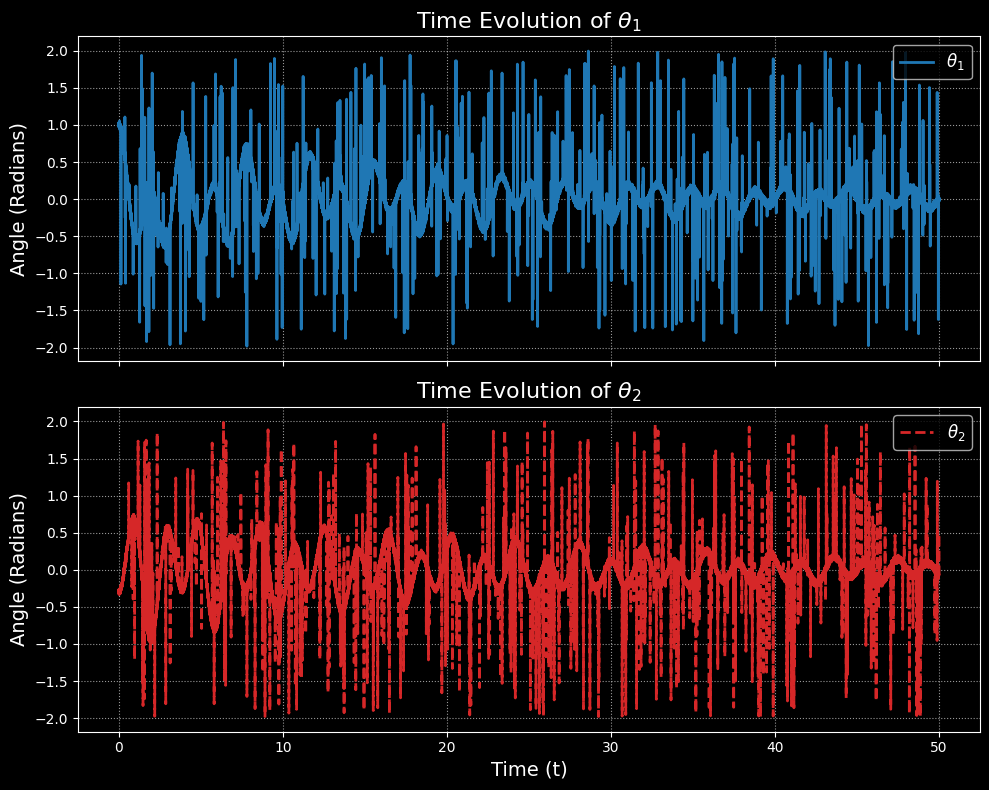

In [44]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

df = pd.read_csv("data.csv")

# Create the figure with two subplots
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

# First subplot for theta_1
ax1.plot(df['t'], df['theta_1'], color='tab:blue', linewidth=2)
ax1.set_title(r'Time Evolution of $\theta_1$', fontsize=16)
ax1.set_ylabel('Angle (Radians)', fontsize=14)
ax1.grid(True, linestyle=':', alpha=0.6)
ax1.legend([r'$\theta_1$'], loc='upper right', fontsize=12)


ax2.plot(df['t'], df['theta_2'], color='tab:red', linestyle='--', linewidth=2)
ax2.set_title(r'Time Evolution of $\theta_2$', fontsize=16)
ax2.set_xlabel('Time (t)', fontsize=14)
ax2.set_ylabel('Angle (Radians)', fontsize=14)
ax2.grid(True, linestyle=':', alpha=0.6)
ax2.legend([r'$\theta_2$'], loc='upper right', fontsize=12)

plt.tight_layout()
plt.savefig('theta_evolution.png', dpi=300, bbox_inches='tight')
plt.show()


# After indtroducing sliding window imputation

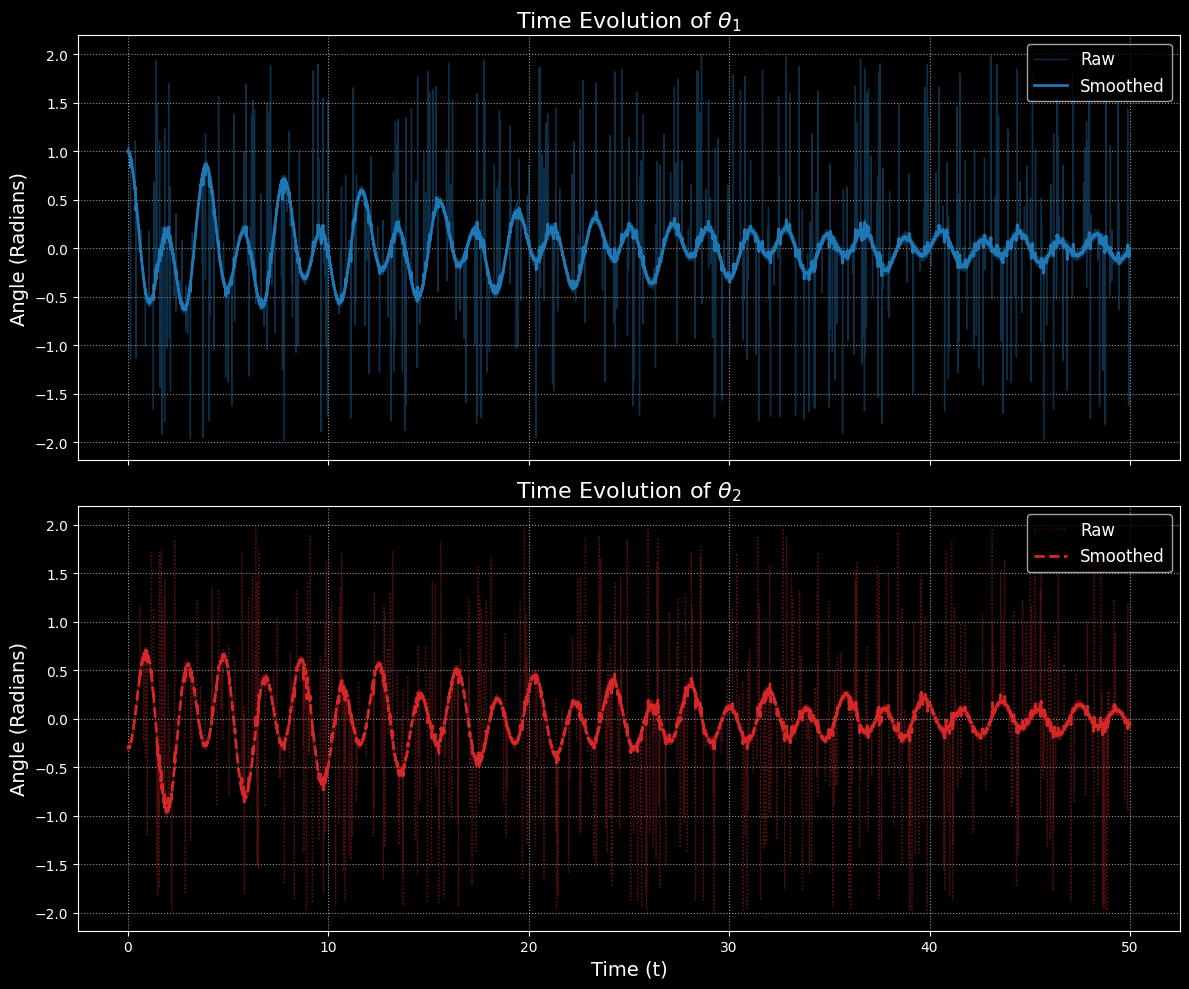

In [50]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.ndimage import uniform_filter1d

df = pd.read_csv("data.csv")

window_size = 21
df['theta_1_smooth'] = uniform_filter1d(df['theta_1'], size=window_size, mode='nearest')
df['theta_2_smooth'] = uniform_filter1d(df['theta_2'], size=window_size, mode='nearest')

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10), sharex=True)

ax1.plot(df['t'], df['theta_1'], color='tab:blue', alpha=0.4, linewidth=1, label='Raw')
ax1.plot(df['t'], df['theta_1_smooth'], color='tab:blue', linewidth=2, label='Smoothed')
ax1.set_title(r'Time Evolution of $\theta_1$', fontsize=16)
ax1.set_ylabel('Angle (Radians)', fontsize=14)
ax1.grid(True, linestyle=':', alpha=0.6)
ax1.legend(loc='upper right', fontsize=12)

ax2.plot(df['t'], df['theta_2'], color='tab:red', alpha=0.4, linewidth=1, linestyle=':', label='Raw')
ax2.plot(df['t'], df['theta_2_smooth'], color='tab:red', linewidth=2, linestyle='--', label='Smoothed')
ax2.set_title(r'Time Evolution of $\theta_2$', fontsize=16)
ax2.set_xlabel('Time (t)', fontsize=14)
ax2.set_ylabel('Angle (Radians)', fontsize=14)
ax2.grid(True, linestyle=':', alpha=0.6)
ax2.legend(loc='upper right', fontsize=12)

plt.tight_layout()
plt.savefig('theta_evolution_smoothed.png', dpi=300, bbox_inches='tight')
plt.show()


But this this still produces very noisy derivatives , so applying an advanced filter+ zscore based outlier reomoval

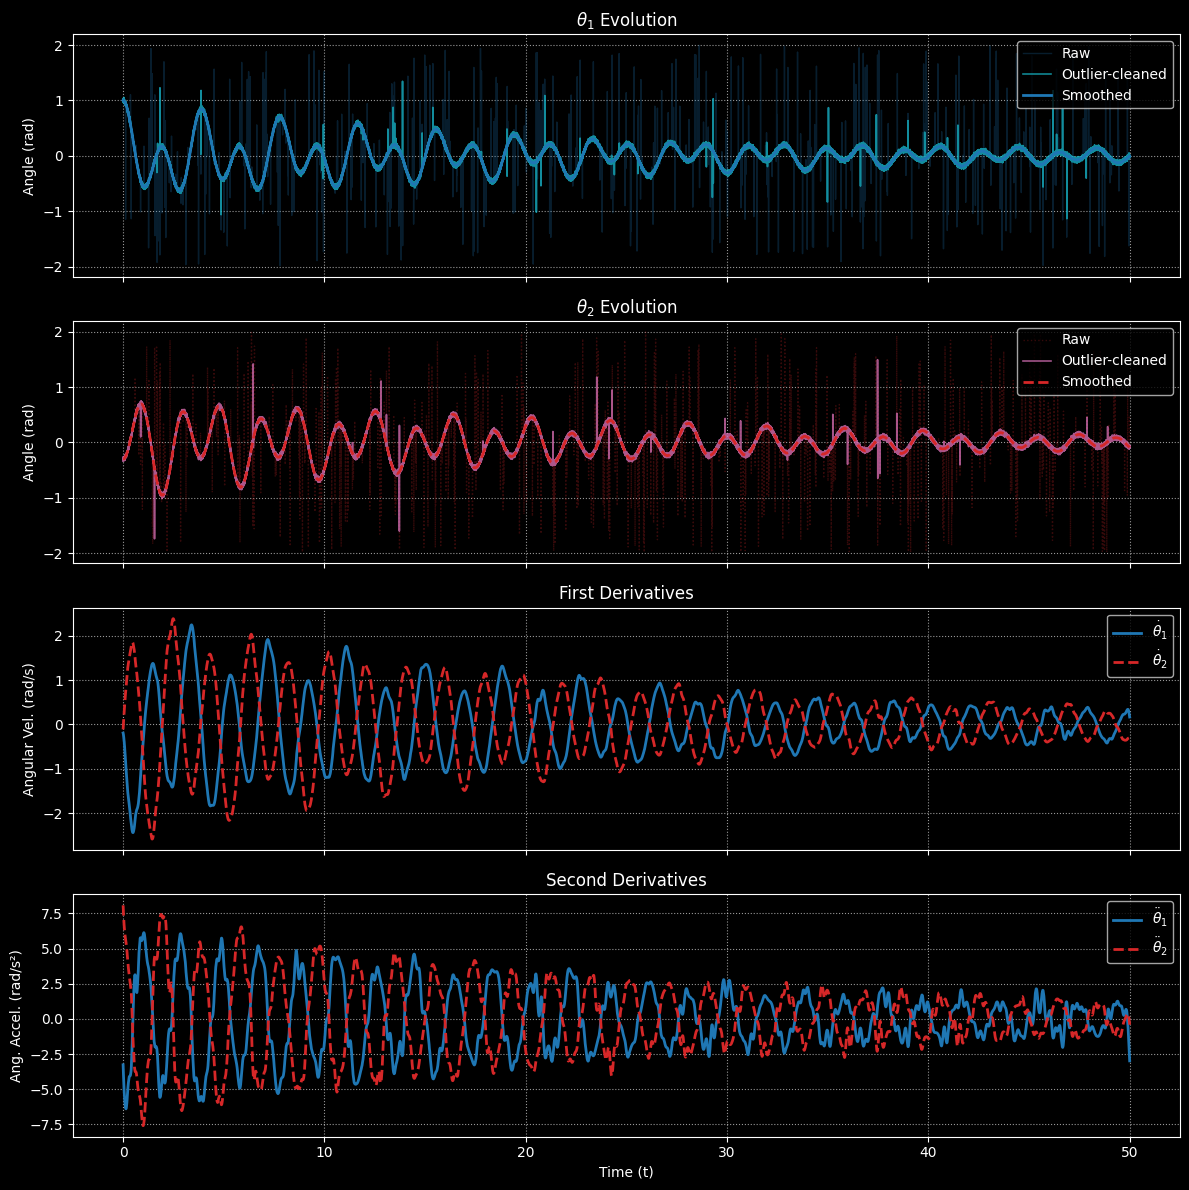

In [74]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.signal import savgol_filter

df = pd.read_csv("data.csv")

t = df["t"].values
theta1 = df["theta_1"].values.astype(float)
theta2 = df["theta_2"].values.astype(float)

win_out = 21
k = 3.0

med1 = pd.Series(theta1).rolling(win_out, center=True, min_periods=1).median().to_numpy()
std1 = pd.Series(theta1).rolling(win_out, center=True, min_periods=1).std().to_numpy()
med2 = pd.Series(theta2).rolling(win_out, center=True, min_periods=1).median().to_numpy()
std2 = pd.Series(theta2).rolling(win_out, center=True, min_periods=1).std().to_numpy()

mask1 = np.abs(theta1 - med1) > k * std1
mask2 = np.abs(theta2 - med2) > k * std2

theta1_clean = theta1.copy()
theta2_clean = theta2.copy()
theta1_clean[mask1] = np.nan
theta2_clean[mask2] = np.nan

theta1_clean = pd.Series(theta1_clean).interpolate(limit_direction="both").to_numpy()
theta2_clean = pd.Series(theta2_clean).interpolate(limit_direction="both").to_numpy()

df["theta_1_clean"] = theta1_clean
df["theta_2_clean"] = theta2_clean

window_length = 251
polyorder = 3

df["theta_1_smooth"] = savgol_filter(df["theta_1_clean"], window_length, polyorder)
df["theta_2_smooth"] = savgol_filter(df["theta_2_clean"], window_length, polyorder)

dt = np.mean(np.diff(df["t"]))

df["theta_1_d1"] = savgol_filter(df["theta_1_smooth"], window_length, polyorder, deriv=1, delta=dt)
df["theta_1_d1"] = savgol_filter(df["theta_1_d1"], window_length + 50, 3)
df["theta_1_d2"] = savgol_filter(df["theta_1_smooth"], window_length, polyorder, deriv=2, delta=dt)
df["theta_1_d2"] = savgol_filter(df["theta_1_d2"], window_length + 50, 3)

df["theta_2_d1"] = savgol_filter(df["theta_2_smooth"], window_length, polyorder, deriv=1, delta=dt)
df["theta_2_d1"] = savgol_filter(df["theta_2_d1"], window_length + 50, 3)
df["theta_2_d2"] = savgol_filter(df["theta_2_smooth"], window_length, polyorder, deriv=2, delta=dt)
df["theta_2_d2"] = savgol_filter(df["theta_2_d2"], window_length + 50, 3)

fig, axes = plt.subplots(4, 1, figsize=(12, 12), sharex=True)

axes[0].plot(df["t"], df["theta_1"], color="tab:blue", alpha=0.25, linewidth=1, label="Raw")
axes[0].plot(df["t"], df["theta_1_clean"], color="tab:cyan", alpha=0.7, linewidth=1.2, label="Outlier-cleaned")
axes[0].plot(df["t"], df["theta_1_smooth"], color="tab:blue", linewidth=2, label="Smoothed")
axes[0].set_title(r"$\theta_1$ Evolution")
axes[0].set_ylabel("Angle (rad)")
axes[0].grid(True, linestyle=":", alpha=0.6)
axes[0].legend(loc="upper right", fontsize=10)

axes[1].plot(df["t"], df["theta_2"], color="tab:red", alpha=0.25, linewidth=1, linestyle=":", label="Raw")
axes[1].plot(df["t"], df["theta_2_clean"], color="tab:pink", alpha=0.7, linewidth=1.2, label="Outlier-cleaned")
axes[1].plot(df["t"], df["theta_2_smooth"], color="tab:red", linewidth=2, linestyle="--", label="Smoothed")
axes[1].set_title(r"$\theta_2$ Evolution")
axes[1].set_ylabel("Angle (rad)")
axes[1].grid(True, linestyle=":", alpha=0.6)
axes[1].legend(loc="upper right", fontsize=10)

axes[2].plot(df["t"], df["theta_1_d1"], color="tab:blue", linewidth=2, label=r"$\dot{\theta}_1$")
axes[2].plot(df["t"], df["theta_2_d1"], color="tab:red", linewidth=2, linestyle="--", label=r"$\dot{\theta}_2$")
axes[2].set_title("First Derivatives")
axes[2].set_ylabel("Angular Vel. (rad/s)")
axes[2].grid(True, linestyle=":", alpha=0.6)
axes[2].legend(loc="upper right", fontsize=10)

axes[3].plot(df["t"], df["theta_1_d2"], color="tab:blue", linewidth=2, label=r"$\ddot{\theta}_1$")
axes[3].plot(df["t"], df["theta_2_d2"], color="tab:red", linewidth=2, linestyle="--", label=r"$\ddot{\theta}_2$")
axes[3].set_title("Second Derivatives")
axes[3].set_xlabel("Time (t)")
axes[3].set_ylabel("Ang. Accel. (rad/s²)")
axes[3].grid(True, linestyle=":", alpha=0.6)
axes[3].legend(loc="upper right", fontsize=10)

plt.tight_layout()
plt.savefig("theta_evolution_savgol_outlier.png", dpi=300, bbox_inches="tight")
plt.show()


In [75]:
print(df.head())

          t   theta_1   theta_2  theta_1_clean  theta_2_clean  theta_1_smooth  \
0  0.000804  0.999619 -0.301766       0.999619      -0.301766        1.004290   
1  0.002516  1.024146 -0.269928       1.024146      -0.269928        1.004115   
2  0.003883  1.012489 -0.332186       1.012489      -0.332186        1.003937   
3  0.005040  0.983864 -0.296065       0.983864      -0.296065        1.003755   
4  0.005500  1.035686 -0.319004       1.035686      -0.319004        1.003570   

   theta_2_smooth  theta_1_d1  theta_1_d2  theta_2_d1  theta_2_d2  
0       -0.295208   -0.194522   -3.267373   -0.112180    8.080310  
1       -0.295388   -0.196188   -3.308668   -0.104580    8.046258  
2       -0.295558   -0.197927   -3.349697   -0.096999    8.012538  
3       -0.295719   -0.199741   -3.390459   -0.089437    7.979149  
4       -0.295870   -0.201627   -3.430956   -0.081896    7.946088  


We will now use linear regression

In [76]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression


t = df["t"].values
th1 = df["theta_1_smooth"].values
th2 = df["theta_2_smooth"].values
th1_d1 = df["theta_1_d1"].values
th1_d2 = df["theta_1_d2"].values
th2_d1 = df["theta_2_d1"].values
th2_d2 = df["theta_2_d2"].values

X1 = np.column_stack([
    -th1_d1,
    -th1,
    -(th1 - th2)
])
y1 = th1_d2

reg1 = LinearRegression(fit_intercept=False)
reg1.fit(X1, y1)
c1, k1, kc1 = reg1.coef_

X2 = np.column_stack([
    -th2_d1,
    -th2,
    -(th2 - th1)
])
y2 = th2_d2

reg2 = LinearRegression(fit_intercept=False)
reg2.fit(X2, y2)
c2, k2, kc2 = reg2.coef_

kc = 0.5 * (kc1 + kc2)

print("c1 =", c1)
print("k1 =", k1)
print("c2 =", c2)
print("k2 =", k2)
print("kc from eq1 =", kc1)
print("kc from eq2 =", kc2)
print("kc average =", kc)


c1 = 0.08891790914726902
k1 = 1.9358578946962597
c2 = 0.06068999074869373
k2 = 2.9359641794066196
kc from eq1 = 3.947830596162961
kc from eq2 = 3.9837434260788416
kc average = 3.9657870111209013
